# GRU soft sensor v14.1

ファイル版: `GRU_soft_sensor_simulation_v14_1_10.ipynb`

| 入力 | 推定器 | モデル名 |
|---|---|---|
| 生センサ＋操作入力 | MLP | `direct_mlp` |
| 生センサ＋操作入力 | GRU | `direct_gru` |
| latent＋操作入力 | MLP | `latent_mlp` |
| latent＋操作入力 | GRU | `latent_gru` |

真の品質、内部状態、AR外乱はシミュレーター内だけで利用できる診断値であり、学習やモデル選択には使用しない。

## 1. Import

In [51]:
mount = True
if mount:
  from google.colab import drive
  drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
import copy
import json
import math
import os
import platform
import random
import shutil
import sys
import time
import traceback
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cuda


## 2. 設定

`run_mode` は `smoke` または `full` を指定する。`smoke` は処理経路の確認用で、性能評価には使わない。

In [53]:
@dataclass
class Config:
    run_mode: str = "full"
    seeds: tuple = (42, 43, 44, 45, 46)

    T: int = 50_000
    train_ratio: float = 0.60
    val_ratio: float = 0.20

    quality_interval: int = 150
    quality_delay: int = 40
    encoder_length: int = 64
    quality_length: int = 64
    train_label_count: int = 50

    x_dim: int = 4
    u_dim: int = 2
    z_dim: int = 8
    hidden_dim: int = 48

    dynamics_rollout: int = 20
    dynamics_batch_size: int = 128
    quality_batch_size: int = 32

    dynamics_epochs: int = 35
    quality_epochs: int = 50
    curriculum_epochs: int = 15
    dynamics_patience: int = 8
    quality_patience: int = 10
    min_delta: float = 1e-5

    learning_rate: float = 1e-3
    weight_decay: float = 1e-5

    drift_amp: float = 0.12
    drift_rho: float = 0.995
    quality_noise_std: float = 0.75
    outlier_rate: float = 0.05
    outlier_std: float = 2.0

    show_progress: bool = True


CFG = Config()
if CFG.run_mode not in {"smoke", "full"}:
    raise ValueError("run_mode must be 'smoke' or 'full'")

if CFG.run_mode == "smoke":
    CFG.seeds = (42,)
    CFG.T = 1_200
    CFG.quality_interval = 30
    CFG.quality_delay = 8
    CFG.encoder_length = 12
    CFG.quality_length = 12
    CFG.train_label_count = 12
    CFG.hidden_dim = 12
    CFG.dynamics_rollout = 3
    CFG.dynamics_epochs = 2
    CFG.quality_epochs = 2
    CFG.curriculum_epochs = 2
    CFG.dynamics_patience = 2
    CFG.quality_patience = 2
    CFG.quality_batch_size = 8
    if not torch.cuda.is_available():
        torch.set_num_threads(1)

print(json.dumps(asdict(CFG), indent=2, ensure_ascii=False))

{
  "run_mode": "full",
  "seeds": [
    42,
    43,
    44,
    45,
    46
  ],
  "T": 50000,
  "train_ratio": 0.6,
  "val_ratio": 0.2,
  "quality_interval": 150,
  "quality_delay": 40,
  "encoder_length": 64,
  "quality_length": 64,
  "train_label_count": 50,
  "x_dim": 4,
  "u_dim": 2,
  "z_dim": 8,
  "hidden_dim": 48,
  "dynamics_rollout": 20,
  "dynamics_batch_size": 128,
  "quality_batch_size": 32,
  "dynamics_epochs": 35,
  "quality_epochs": 50,
  "curriculum_epochs": 15,
  "dynamics_patience": 8,
  "quality_patience": 10,
  "min_delta": 1e-05,
  "learning_rate": 0.001,
  "weight_decay": 1e-05,
  "drift_amp": 0.12,
  "drift_rho": 0.995,
  "quality_noise_std": 0.75,
  "outlier_rate": 0.05,
  "outlier_std": 2.0,
  "show_progress": true
}


## 3. 保存と共通関数

結果の保存、seed固定、標準化、MAE計算をここにまとめる。

実行中の結果は一時フォルダへ保存し、正常終了したときだけ `smoke` または `full` の結果フォルダへ切り替える。再実行が途中で失敗しても、直前に正常終了した結果を残すためである。

JSONとCSVも一時ファイルを挟んでから置き換える。実行環境はJSONへ記録する。

In [54]:
RESULT_ROOT = Path("GRU_soft_sensor_simulation_v14_1_10_results")
FINAL_DIR = RESULT_ROOT / CFG.run_mode
RUN_DIR = RESULT_ROOT / f".{CFG.run_mode}_working"
BACKUP_DIR = RESULT_ROOT / f".{CFG.run_mode}_previous"

RESULT_ROOT.mkdir(parents=True, exist_ok=True)
if RUN_DIR.exists():
    shutil.rmtree(RUN_DIR)
RUN_DIR.mkdir(parents=True, exist_ok=True)

(RUN_DIR / "RUNNING").write_text("running\n", encoding="utf-8")


def save_json(name, obj):
    path = RUN_DIR / name
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
    tmp.replace(path)


def save_csv(name, frame):
    path = RUN_DIR / name
    tmp = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(tmp, index=False)
    tmp.replace(path)


def save_figure(fig, name):
    path = RUN_DIR / name
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def progress(iterable, desc, total=None, leave=False):
    return tqdm(
        iterable,
        desc=desc,
        total=total,
        leave=leave,
        dynamic_ncols=True,
        disable=not CFG.show_progress,
    )


def causal_moving_average(a, width):
    a = np.asarray(a, dtype=np.float32)
    c = np.cumsum(np.insert(a, 0, 0.0))
    out = np.empty_like(a)
    out[: width - 1] = c[1:width] / np.arange(1, width)
    out[width - 1 :] = (c[width:] - c[:-width]) / width
    return out.astype(np.float32)


def standardize_train(array, train_end, eps=1e-6):
    mean = array[:train_end].mean(axis=0, keepdims=True)
    std = array[:train_end].std(axis=0, keepdims=True)
    std = np.maximum(std, eps)
    scaled = (array - mean) / std
    return scaled.astype(np.float32), mean.astype(np.float32), std.astype(np.float32)


def safe_mae(y_true, y_pred):
    return float(mean_absolute_error(np.asarray(y_true), np.asarray(y_pred)))


def parameter_count(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))


ENVIRONMENT = {
    "python": sys.version,
    "platform": platform.platform(),
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "cudnn_version": torch.backends.cudnn.version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "device": str(DEVICE),
}
save_json("config.json", asdict(CFG))
save_json("environment.json", ENVIRONMENT)

## 4. シミュレーター

仮想センサ4個と操作入力2個を作る。品質は内部状態の過去値から作り、AR外乱は品質出力だけに加える。

品質推定器にはセンサと操作入力だけを渡す。真の品質と外乱は入力に含めず、実データでは見えない値を使わないようにする。

In [55]:
def make_ar_drift(T, seed, amp, rho):
    rng = np.random.default_rng(seed)
    innovation_std = amp * np.sqrt(max(1e-8, 1.0 - rho**2))
    drift = np.zeros(T, dtype=np.float32)
    drift[0] = rng.normal(0.0, amp)
    for t in range(1, T):
        drift[t] = rho * drift[t - 1] + rng.normal(0.0, innovation_std)
    return drift


def simulate_old_process(cfg, seed):
    process_rng = np.random.default_rng(seed)
    sensor_rng = np.random.default_rng(seed + 10_000)
    drift = make_ar_drift(
        cfg.T,
        seed + 20_000,
        cfg.drift_amp,
        cfg.drift_rho,
    )

    U = np.zeros((cfg.T, cfg.u_dim), dtype=np.float32)
    S = np.zeros((cfg.T, cfg.x_dim), dtype=np.float32)
    S[0] = np.array([55.0, 1.05, 1.00, 1.00], dtype=np.float32)

    sp_temp = 58.0 + 3.0 * np.sin(np.linspace(0, 5.5 * np.pi, cfg.T))
    sp_conc = 1.10 + 0.08 * np.sin(
        np.linspace(0, 4.0 * np.pi, cfg.T) + 1.0
    )

    for t in range(1, cfg.T):
        if t % 400 == 0:
            U[t] = U[t - 1] + process_rng.normal(0, [0.8, 0.4])
        else:
            U[t] = 0.995 * U[t - 1] + process_rng.normal(0, [0.02, 0.01])
        U[t] = np.clip(U[t], [-3.0, -2.0], [3.0, 2.0])

        temp, conc, press, visc = S[t - 1]
        pulse = process_rng.normal(0, 3.0) if process_rng.random() < 0.004 else 0.0

        temp_target = sp_temp[t] + 0.9 * U[t, 0] - 1.5 * U[t, 1]
        conc_target = sp_conc[t] + 0.06 * U[t, 1] - 0.02 * U[t, 0]
        press_target = 1.00 + 0.10 * U[t, 1] + 0.015 * (temp - 58.0)
        visc_target = 1.00 + 0.55 * (conc - 1.10) - 0.012 * (temp - 58.0)

        S[t, 0] = (
            temp
            + 0.035 * (temp_target - temp)
            + process_rng.normal(0, 0.20)
            + pulse
        )
        S[t, 1] = (
            conc
            + 0.045 * (conc_target - conc)
            + process_rng.normal(0, 0.008)
        )
        S[t, 2] = (
            press
            + 0.060 * (press_target - press)
            + process_rng.normal(0, 0.006)
        )
        S[t, 3] = (
            visc
            + 0.040 * (visc_target - visc)
            + process_rng.normal(0, 0.010)
        )

    X = S + sensor_rng.normal(
        0,
        [0.08, 0.003, 0.003, 0.004],
        size=S.shape,
    )

    signal = (
        0.22 * (causal_moving_average(S[:, 0], 45) - 58.0)
        + 4.0 * (causal_moving_average(S[:, 1], 35) - 1.10)
        - 2.5 * (causal_moving_average(S[:, 2], 25) - 1.00)
        + 1.8 * (causal_moving_average(S[:, 3], 60) - 1.00)
    )
    q_true = (93.0 + signal + drift).astype(np.float32)

    return X.astype(np.float32), U.astype(np.float32), q_true, drift, S


def build_data(cfg, seed):
    train_end = int(cfg.T * cfg.train_ratio)
    val_end = int(cfg.T * (cfg.train_ratio + cfg.val_ratio))

    X_raw, U_raw, q_true, drift, state_true = simulate_old_process(cfg, seed)
    X, X_mean, X_std = standardize_train(X_raw, train_end)
    U, U_mean, U_std = standardize_train(U_raw, train_end)

    start = max(60, cfg.encoder_length + cfg.quality_length)
    feature_times = np.arange(
        start,
        cfg.T - cfg.quality_delay,
        cfg.quality_interval,
        dtype=int,
    )
    measurement_times = feature_times + cfg.quality_delay

    measurement_rng = np.random.default_rng(seed + 30_000)
    q_obs = q_true[feature_times].copy()
    q_obs += measurement_rng.normal(
        0,
        cfg.quality_noise_std,
        size=len(q_obs),
    )
    outlier_mask = measurement_rng.random(len(q_obs)) < cfg.outlier_rate
    q_obs[outlier_mask] += measurement_rng.normal(
        0,
        cfg.outlier_std,
        size=int(outlier_mask.sum()),
    )

    base_train_mask = measurement_times < train_end
    q_val_mask = (feature_times >= train_end) & (measurement_times < val_end)
    q_test_mask = feature_times >= val_end

    train_indices = np.where(base_train_mask)[0]
    keep_count = min(cfg.train_label_count, len(train_indices))
    subset_rng = np.random.default_rng(seed + 40_000)
    selected = np.sort(subset_rng.permutation(train_indices)[:keep_count])
    q_train_mask = np.zeros_like(base_train_mask, dtype=bool)
    q_train_mask[selected] = True

    if not q_train_mask.any() or not q_val_mask.any() or not q_test_mask.any():
        raise ValueError("quality split is empty")

    q_mean = np.float32(q_obs[q_train_mask].mean())
    q_std = np.float32(max(q_obs[q_train_mask].std(), 1e-6))
    q_obs_scaled = ((q_obs - q_mean) / q_std).astype(np.float32)

    assert feature_times.min() >= cfg.encoder_length + cfg.quality_length
    assert np.all(measurement_times[q_train_mask] < train_end)
    assert np.all(feature_times[q_val_mask] >= train_end)
    assert np.all(measurement_times[q_val_mask] < val_end)
    assert np.all(feature_times[q_test_mask] >= val_end)

    return {
        "X": X,
        "U": U,
        "X_raw": X_raw,
        "U_raw": U_raw,
        "q_true": q_true,
        "q_obs": q_obs.astype(np.float32),
        "q_obs_scaled": q_obs_scaled,
        "q_mean": q_mean,
        "q_std": q_std,
        "drift": drift,
        "state_true": state_true,
        "feature_times": feature_times,
        "measurement_times": measurement_times,
        "q_train_mask": q_train_mask,
        "q_val_mask": q_val_mask,
        "q_test_mask": q_test_mask,
        "train_end": train_end,
        "val_end": val_end,
        "X_mean": X_mean,
        "X_std": X_std,
        "U_mean": U_mean,
        "U_std": U_std,
        "n_train_labels": int(q_train_mask.sum()),
        "n_val_labels": int(q_val_mask.sum()),
        "n_test_labels": int(q_test_mask.sum()),
    }

## 4.1 シミュレーターの確認

最初のseedだけを代表として表示する。

観測センサ、操作入力、品質、AR外乱を最初に確認し、その後に内部状態と観測センサ、品質測定の遅延を確認する。真の品質、内部状態、AR外乱は診断専用。

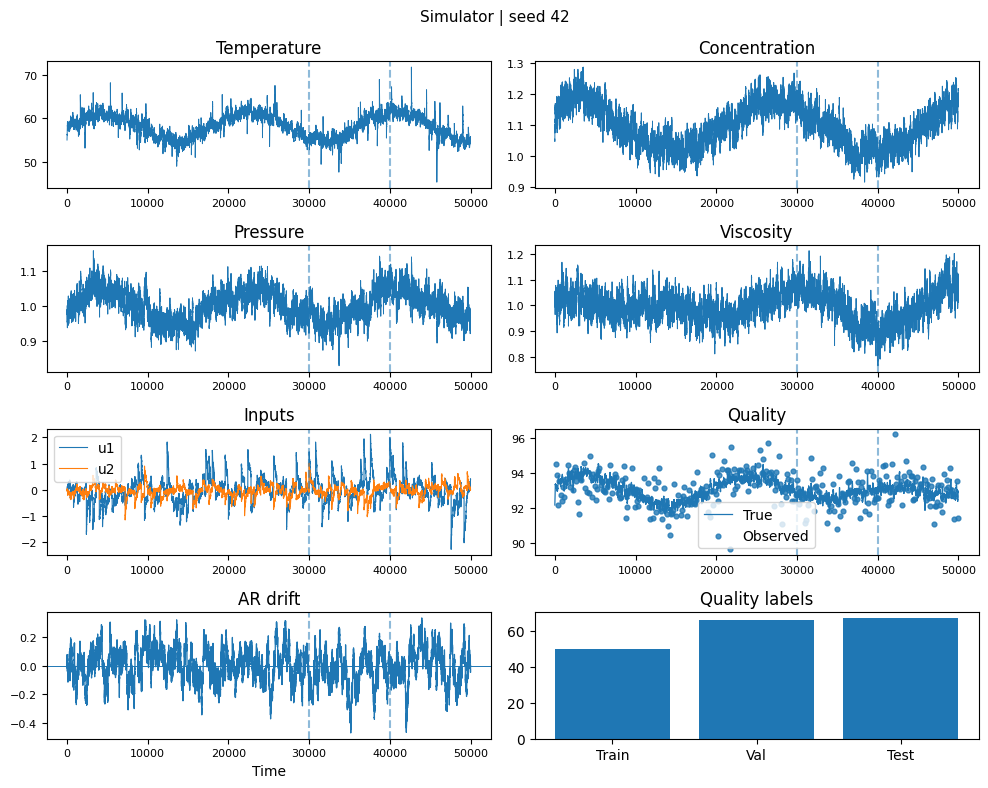

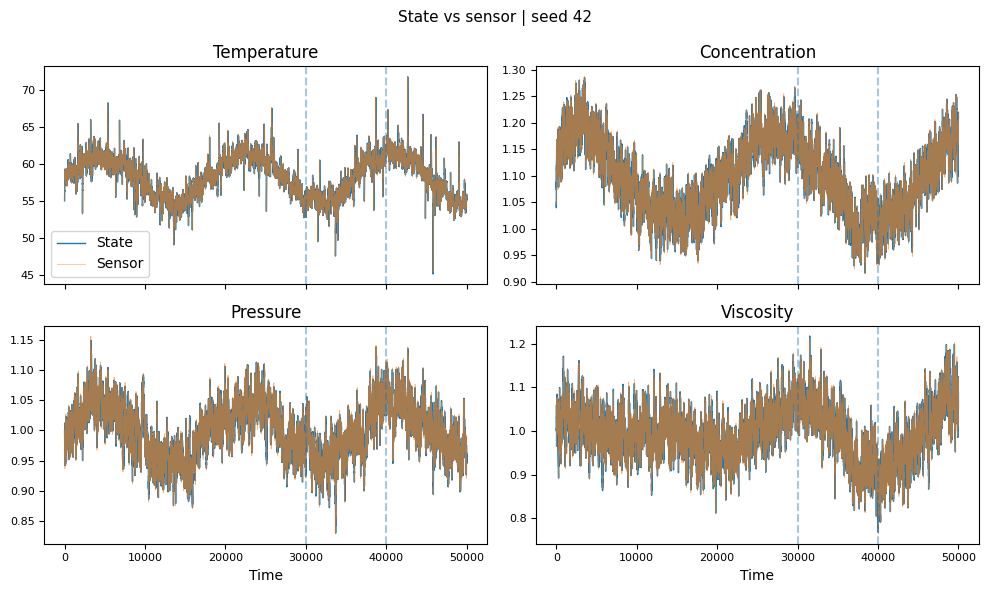

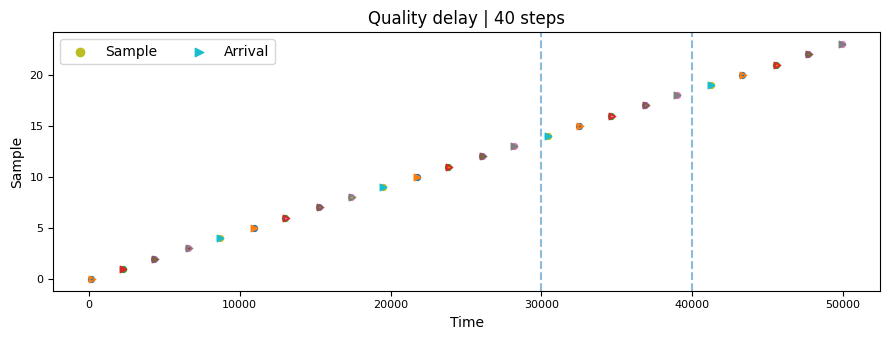

In [56]:
VISUALIZATION_SEED = int(CFG.seeds[0])
visualization_data = build_data(CFG, VISUALIZATION_SEED)
sensor_names = ["Temperature", "Concentration", "Pressure", "Viscosity"]
time_index = np.arange(CFG.T)

fig, axes = plt.subplots(4, 2, figsize=(10, 8))
sensor_axes = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]

for sensor_index, ax in enumerate(sensor_axes):
    ax.plot(time_index, visualization_data["X_raw"][:, sensor_index], linewidth=0.7)
    ax.set_title(sensor_names[sensor_index])

for input_index in range(CFG.u_dim):
    axes[2, 0].plot(
        time_index,
        visualization_data["U_raw"][:, input_index],
        linewidth=0.8,
        label=f"u{input_index + 1}",
    )
axes[2, 0].set_title("Inputs")
axes[2, 0].legend()

axes[2, 1].plot(
    time_index,
    visualization_data["q_true"],
    linewidth=0.9,
    label="True",
)
axes[2, 1].scatter(
    visualization_data["feature_times"],
    visualization_data["q_obs"],
    s=12,
    alpha=0.8,
    label="Observed",
)
axes[2, 1].set_title("Quality")
axes[2, 1].legend()

axes[3, 0].plot(time_index, visualization_data["drift"], linewidth=0.9)
axes[3, 0].axhline(0.0, linewidth=0.7)
axes[3, 0].set_title("AR drift")
axes[3, 0].set_xlabel("Time")

label_counts = [
    visualization_data["n_train_labels"],
    visualization_data["n_val_labels"],
    visualization_data["n_test_labels"],
]
axes[3, 1].bar(["Train", "Val", "Test"], label_counts)
axes[3, 1].set_title("Quality labels")

for ax in [*sensor_axes, axes[2, 0], axes[2, 1], axes[3, 0]]:
    ax.axvline(visualization_data["train_end"], linestyle="--", alpha=0.5)
    ax.axvline(visualization_data["val_end"], linestyle="--", alpha=0.5)
    ax.tick_params(labelsize=8)

fig.suptitle(f"Simulator | seed {VISUALIZATION_SEED}", fontsize=11)
fig.tight_layout()
save_figure(fig, f"simulator_overview_seed{VISUALIZATION_SEED}.png")

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
axes = axes.ravel()

for sensor_index, ax in enumerate(axes):
    ax.plot(
        time_index,
        visualization_data["state_true"][:, sensor_index],
        linewidth=1.0,
        label="State",
    )
    ax.plot(
        time_index,
        visualization_data["X_raw"][:, sensor_index],
        linewidth=0.5,
        alpha=0.6,
        label="Sensor",
    )
    ax.axvline(visualization_data["train_end"], linestyle="--", alpha=0.4)
    ax.axvline(visualization_data["val_end"], linestyle="--", alpha=0.4)
    ax.set_title(sensor_names[sensor_index])
    ax.tick_params(labelsize=8)

axes[0].legend()
axes[2].set_xlabel("Time")
axes[3].set_xlabel("Time")
fig.suptitle(f"State vs sensor | seed {VISUALIZATION_SEED}", fontsize=11)
fig.tight_layout()
save_figure(fig, f"simulator_state_vs_sensor_seed{VISUALIZATION_SEED}.png")

delay_count = min(24, len(visualization_data["feature_times"]))
delay_indices = np.linspace(
    0,
    len(visualization_data["feature_times"]) - 1,
    delay_count,
    dtype=int,
)
fig, ax = plt.subplots(figsize=(9, 3.5))

for display_index, sample_index in enumerate(delay_indices):
    sample_time = int(visualization_data["feature_times"][sample_index])
    arrival_time = int(visualization_data["measurement_times"][sample_index])
    ax.plot([sample_time, arrival_time], [display_index, display_index], linewidth=1.0)
    ax.scatter(sample_time, display_index, marker="o", s=18)
    ax.scatter(arrival_time, display_index, marker=">", s=22)

ax.scatter([], [], marker="o", label="Sample")
ax.scatter([], [], marker=">", label="Arrival")
ax.axvline(visualization_data["train_end"], linestyle="--", alpha=0.5)
ax.axvline(visualization_data["val_end"], linestyle="--", alpha=0.5)
ax.set_xlabel("Time")
ax.set_ylabel("Sample")
ax.set_title(f"Quality delay | {CFG.quality_delay} steps")
ax.legend(ncol=2)
ax.tick_params(labelsize=8)
fig.tight_layout()
save_figure(fig, f"quality_delay_timeline_seed{VISUALIZATION_SEED}.png")

## 5. Dataset

センサ予測用と品質推定用でDatasetを分ける。

センサ予測では、過去履歴から将来センサを複数step予測する。品質推定では品質の対象時刻を `t` として、入力区間を `[t - L, t)` に固定する。時刻 `t` のセンサは入れず、未来情報が混ざらないようにする。

In [57]:
class DynamicsDataset(Dataset):
    def __init__(self, X, U, start, end, history, rollout):
        self.X = torch.from_numpy(X)
        self.U = torch.from_numpy(U)
        self.history = history
        self.rollout = rollout
        lo = max(start, history)
        hi = min(end - rollout + 1, len(X) - rollout + 1)
        self.times = np.arange(lo, max(lo, hi), dtype=int)

    def __len__(self):
        return len(self.times)

    def __getitem__(self, index):
        t = int(self.times[index])
        return (
            self.X[t - self.history : t],
            self.U[t - self.history : t],
            self.U[t : t + self.rollout],
            self.X[t : t + self.rollout],
        )


class QualityDataset(Dataset):
    def __init__(self, features, targets, feature_times, history, mask):
        self.features = torch.from_numpy(features)
        self.targets = torch.from_numpy(targets.astype(np.float32))
        selected = np.where(mask)[0]
        self.times = feature_times[selected]
        self.label_indices = selected
        self.history = history

    def __len__(self):
        return len(self.times)

    def __getitem__(self, index):
        t = int(self.times[index])
        label_index = int(self.label_indices[index])
        return (
            self.features[t - self.history : t],
            self.targets[label_index],
            label_index,
        )

## 6. センサ予測モデル

センサと操作入力の履歴をGRU encoderへ入れ、8次元latentを作る。操作入力でlatentを進め、将来センサを最大20 step予測する。

学習の最初は短い予測から始め、少しずつrolloutを延ばす。いきなり20 stepを学習するより安定しやすそう。

ここでは品質ラベルを使わない。validationでは、モデル予測と直前値を維持するだけの予測を比べる。

In [58]:
class ResidualLatentDynamics(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = nn.GRU(
            cfg.x_dim + cfg.u_dim,
            cfg.hidden_dim,
            batch_first=True,
        )
        self.to_z = nn.Linear(cfg.hidden_dim, cfg.z_dim)
        self.transition = nn.Sequential(
            nn.Linear(cfg.z_dim + cfg.u_dim, cfg.hidden_dim),
            nn.Tanh(),
            nn.Linear(cfg.hidden_dim, cfg.z_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(cfg.z_dim, cfg.hidden_dim),
            nn.ReLU(),
            nn.Linear(cfg.hidden_dim, cfg.x_dim),
        )

    def encode(self, x_history, u_history):
        sequence = torch.cat([x_history, u_history], dim=-1)
        _, hidden = self.encoder(sequence)
        return self.to_z(hidden[-1])

    def step(self, z, u):
        delta = self.transition(torch.cat([z, u], dim=-1))
        return z + delta

    def rollout(self, x_history, u_history, u_future, steps=None):
        z = self.encode(x_history, u_history)
        steps = u_future.shape[1] if steps is None else steps
        predictions = []
        for k in range(steps):
            z = self.step(z, u_future[:, k])
            predictions.append(self.decoder(z))
        return torch.stack(predictions, dim=1)


@torch.no_grad()
def evaluate_dynamics(model, data, cfg):
    dataset = DynamicsDataset(
        data["X"],
        data["U"],
        data["train_end"],
        data["val_end"],
        cfg.encoder_length,
        cfg.dynamics_rollout,
    )
    loader = DataLoader(dataset, batch_size=cfg.dynamics_batch_size)
    loss_fn = nn.MSELoss()

    model_losses = []
    persistence_losses = []
    model.eval()
    for x_history, u_history, u_future, target in loader:
        x_history = x_history.to(DEVICE)
        u_history = u_history.to(DEVICE)
        u_future = u_future.to(DEVICE)
        target = target.to(DEVICE)

        prediction = model.rollout(x_history, u_history, u_future)
        persistence = x_history[:, -1:, :].expand_as(target)

        model_losses.append(loss_fn(prediction, target).item())
        persistence_losses.append(loss_fn(persistence, target).item())

        if cfg.run_mode == "smoke":
            break

    return float(np.mean(model_losses)), float(np.mean(persistence_losses))


def train_dynamics(data, cfg, seed):
    set_seed(seed)
    model = ResidualLatentDynamics(cfg).to(DEVICE)

    train_dataset = DynamicsDataset(
        data["X"],
        data["U"],
        0,
        data["train_end"],
        cfg.encoder_length,
        cfg.dynamics_rollout,
    )
    val_dataset = DynamicsDataset(
        data["X"],
        data["U"],
        data["train_end"],
        data["val_end"],
        cfg.encoder_length,
        cfg.dynamics_rollout,
    )
    if len(train_dataset) == 0 or len(val_dataset) == 0:
        raise ValueError("dynamics dataset is empty")

    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg.dynamics_batch_size,
        shuffle=True,
        generator=generator,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=cfg.dynamics_batch_size,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )
    loss_fn = nn.MSELoss()

    best_value = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    wait = 0

    epochs = progress(
        range(cfg.dynamics_epochs),
        desc=f"dynamics seed={seed}",
        total=cfg.dynamics_epochs,
    )
    for epoch in epochs:
        if cfg.curriculum_epochs <= 1:
            rollout = cfg.dynamics_rollout
        else:
            fraction = min(1.0, epoch / float(cfg.curriculum_epochs - 1))
            rollout = 1 + int(round(fraction * (cfg.dynamics_rollout - 1)))

        model.train()
        for x_history, u_history, u_future, target in train_loader:
            x_history = x_history.to(DEVICE)
            u_history = u_history.to(DEVICE)
            u_future = u_future[:, :rollout].to(DEVICE)
            target = target[:, :rollout].to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            prediction = model.rollout(
                x_history,
                u_history,
                u_future,
                steps=rollout,
            )
            loss = loss_fn(prediction, target)
            loss.backward()
            optimizer.step()

            if cfg.run_mode == "smoke":
                break

        model.eval()
        values = []
        with torch.no_grad():
            for x_history, u_history, u_future, target in val_loader:
                prediction = model.rollout(
                    x_history.to(DEVICE),
                    u_history.to(DEVICE),
                    u_future.to(DEVICE),
                )
                values.append(loss_fn(prediction, target.to(DEVICE)).item())
                if cfg.run_mode == "smoke":
                    break
        value = float(np.mean(values))

        curriculum_done = epoch >= cfg.curriculum_epochs - 1
        if curriculum_done and value < best_value - cfg.min_delta:
            best_value = value
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            wait = 0
        elif curriculum_done:
            wait += 1

        epochs.set_postfix(
            rollout=rollout,
            val=f"{value:.4f}",
            best=(f"{best_value:.4f}" if np.isfinite(best_value) else "inf"),
        )
        if curriculum_done and wait >= cfg.dynamics_patience:
            break

    epochs.close()
    model.load_state_dict(best_state)
    model.eval()

    val_mse, persistence_mse = evaluate_dynamics(model, data, cfg)
    return model, val_mse, persistence_mse, best_epoch

## 7. Latent抽出と入力整合

学習済みDynamicsから全時刻のlatentを取り出し、train区間の統計量だけで標準化する。

`Z[t]` は `X[t-1]` までを見て作られるため、品質入力では `Z[s+1]` と `X[s]` を対応させる。これで1 stepのずれを避ける。

Direct入力には `[X, U]`、Latent入力には `[Z, U]` を使う。

In [59]:
@torch.no_grad()
def compute_latents(model, X, U, cfg):
    model.eval()
    Z = np.full((len(X), cfg.z_dim), np.nan, dtype=np.float32)
    times = np.arange(cfg.encoder_length, len(X), dtype=int)

    batches = progress(
        range(0, len(times), 256),
        desc="latent extraction",
        total=math.ceil(len(times) / 256),
    )
    for start in batches:
        selected = times[start : start + 256]
        x_history = np.stack(
            [X[t - cfg.encoder_length : t] for t in selected]
        )
        u_history = np.stack(
            [U[t - cfg.encoder_length : t] for t in selected]
        )
        z = model.encode(
            torch.from_numpy(x_history).to(DEVICE),
            torch.from_numpy(u_history).to(DEVICE),
        )
        Z[selected] = z.cpu().numpy()
    batches.close()
    return Z


def standardize_latents(Z, train_end, cfg):
    valid = np.arange(cfg.encoder_length, train_end)
    mean = np.nanmean(Z[valid], axis=0, keepdims=True)
    std = np.maximum(np.nanstd(Z[valid], axis=0, keepdims=True), 1e-6)
    return ((Z - mean) / std).astype(np.float32), mean, std


def align_latents_to_sensor_time(Z):

    aligned = np.full_like(Z, np.nan, dtype=np.float32)
    aligned[:-1] = Z[1:]
    return aligned


def build_quality_features(data, Z_scaled, cfg):
    Z_aligned = align_latents_to_sensor_time(Z_scaled)

    required_start = int(data["feature_times"].min() - cfg.quality_length)
    required_end = int(data["feature_times"].max())
    if not np.isfinite(Z_aligned[required_start:required_end]).all():
        raise ValueError("quality history contains undefined latent values")

    direct = np.concatenate([data["X"], data["U"]], axis=1).astype(np.float32)
    latent = np.concatenate([Z_aligned, data["U"]], axis=1).astype(np.float32)
    return {"direct": direct, "latent": latent}

## 7.1 Dynamicsとlatentの可視化

5 seedの学習がすべて終わった後、最初のseedだけを代表として表示する。

Dynamicsのrolloutでは、将来の観測センサとモデル予測、persistenceを比較する。ここで表示する比較対象は内部状態ではなく、Dynamicsが実際に学習している観測センサ。

latentはPCAで2次元へ落とし、時刻と診断用の真の品質で色付けする。PCAの見え方だけからlatentの物理的意味は判断しない。

In [60]:
def plot_dynamics_rollout(model, data, cfg, seed):
    steps = cfg.dynamics_rollout
    start_time = int(data["val_end"])

    x_history = torch.from_numpy(
        data["X"][start_time - cfg.encoder_length : start_time][None]
    ).to(DEVICE)
    u_history = torch.from_numpy(
        data["U"][start_time - cfg.encoder_length : start_time][None]
    ).to(DEVICE)
    u_future = torch.from_numpy(
        data["U"][start_time : start_time + steps][None]
    ).to(DEVICE)

    model.eval()
    with torch.no_grad():
        prediction_scaled = model.rollout(
            x_history,
            u_history,
            u_future,
            steps=steps,
        )[0].cpu().numpy()

    prediction_raw = prediction_scaled * data["X_std"] + data["X_mean"]
    true_raw = data["X_raw"][start_time : start_time + steps]
    persistence_raw = np.repeat(
        data["X_raw"][start_time - 1][None],
        steps,
        axis=0,
    )
    horizon = np.arange(1, steps + 1)

    fig, axes = plt.subplots(2, 2, figsize=(9, 6))
    axes = axes.ravel()

    for sensor_index, ax in enumerate(axes):
        ax.plot(horizon, true_raw[:, sensor_index], linewidth=1.1, label="Sensor")
        ax.plot(horizon, prediction_raw[:, sensor_index], linewidth=1.1, label="Model")
        ax.plot(horizon, persistence_raw[:, sensor_index], linestyle="--", label="Persist")
        ax.set_title(sensor_names[sensor_index])
        ax.set_xlabel("Horizon")
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.2)

    axes[0].legend()
    fig.suptitle(f"Dynamics rollout | seed {seed}", fontsize=11)
    fig.tight_layout()
    save_figure(fig, f"dynamics_rollout_seed{seed}.png")


def plot_latent_pca(Z_scaled, data, seed):
    finite_mask = np.isfinite(Z_scaled).all(axis=1)
    valid_indices = np.flatnonzero(finite_mask)
    sample_count = min(4000, len(valid_indices))
    selected_positions = np.linspace(
        0,
        len(valid_indices) - 1,
        sample_count,
        dtype=int,
    )
    plot_indices = valid_indices[selected_positions]

    pca = PCA(n_components=2)
    latent_2d = pca.fit_transform(Z_scaled[plot_indices])

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    time_scatter = axes[0].scatter(
        latent_2d[:, 0],
        latent_2d[:, 1],
        c=plot_indices,
        s=6,
        alpha=0.6,
    )
    fig.colorbar(time_scatter, ax=axes[0], label="Time")
    axes[0].set_title("By time")

    quality_scatter = axes[1].scatter(
        latent_2d[:, 0],
        latent_2d[:, 1],
        c=data["q_true"][plot_indices],
        s=6,
        alpha=0.6,
    )
    fig.colorbar(quality_scatter, ax=axes[1], label="True q")
    axes[1].set_title("By quality")

    for ax in axes:
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.tick_params(labelsize=8)

    fig.suptitle(f"Latent PCA | seed {seed}", fontsize=11)
    fig.tight_layout()
    save_figure(fig, f"latent_pca_seed{seed}.png")

## 8. 品質推定器

GRUとMLPには同じ64 stepの履歴を渡す。履歴を使うかどうかではなく、推定器の違いを比べる。

- GRU：`batch × 64 × feature_dim` の時系列入力
- MLP：同じ入力を `batch × (64 × feature_dim)` に平坦化

MLPのhidden幅は、対応するGRUと学習パラメータ数が近くなるように自動で選ぶ。単純なMLPでもかなり強そうなので、比較に加える。

In [61]:
class QualityGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, sequence):
        _, hidden = self.gru(sequence)
        return self.head(hidden[-1]).squeeze(-1)


class QualityMLP(nn.Module):
    def __init__(self, input_dim, sequence_length, hidden_dim):
        super().__init__()
        flattened_dim = input_dim * sequence_length
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, sequence):
        return self.net(sequence).squeeze(-1)


def choose_mlp_hidden_dim(input_dim, sequence_length, target_parameters):
    best_hidden = None
    best_difference = None
    for hidden in range(2, 257):
        candidate = QualityMLP(input_dim, sequence_length, hidden)
        difference = abs(parameter_count(candidate) - target_parameters)
        if best_difference is None or difference < best_difference:
            best_hidden = hidden
            best_difference = difference
    return best_hidden


def make_quality_model(estimator_type, input_dim, cfg):
    if estimator_type == "gru":
        return QualityGRU(input_dim, cfg.hidden_dim)

    if estimator_type == "mlp":
        reference = QualityGRU(input_dim, cfg.hidden_dim)
        target_parameters = parameter_count(reference)
        hidden_dim = choose_mlp_hidden_dim(
            input_dim,
            cfg.quality_length,
            target_parameters,
        )
        return QualityMLP(input_dim, cfg.quality_length, hidden_dim)

    raise ValueError("estimator_type must be 'mlp' or 'gru'")

## 9. 品質推定器の学習と評価

観測品質を教師にして `SmoothL1Loss` で学習する。外れ値の影響を少し抑える狙いがある。

early stoppingもvalidationの観測品質だけで判断する。真の品質は学習とモデル選択に使わず、シミュレーター内の診断指標として保存する。test結果を見てモデルを選ばない。

In [62]:
@torch.no_grad()
def predict_quality(model, features, data, cfg, split):
    mask = data[f"q_{split}_mask"]
    dataset = QualityDataset(
        features,
        data["q_obs_scaled"],
        data["feature_times"],
        cfg.quality_length,
        mask,
    )
    loader = DataLoader(dataset, batch_size=cfg.quality_batch_size)

    predictions = []
    observed = []
    true_values = []
    times = []

    model.eval()
    for sequence, _, label_indices in loader:
        pred_scaled = model(sequence.to(DEVICE)).cpu().numpy()
        pred = pred_scaled * float(data["q_std"]) + float(data["q_mean"])

        label_indices = label_indices.numpy()
        predictions.extend(pred)
        observed.extend(data["q_obs"][label_indices])
        selected_times = data["feature_times"][label_indices]
        true_values.extend(data["q_true"][selected_times])
        times.extend(selected_times)

    return {
        "prediction": np.asarray(predictions, dtype=np.float32),
        "observed": np.asarray(observed, dtype=np.float32),
        "true": np.asarray(true_values, dtype=np.float32),
        "time": np.asarray(times, dtype=int),
    }


def train_quality_estimator(
    features,
    data,
    cfg,
    seed,
    representation,
    estimator_type,
):
    train_dataset = QualityDataset(
        features,
        data["q_obs_scaled"],
        data["feature_times"],
        cfg.quality_length,
        data["q_train_mask"],
    )
    val_dataset = QualityDataset(
        features,
        data["q_obs_scaled"],
        data["feature_times"],
        cfg.quality_length,
        data["q_val_mask"],
    )
    if len(train_dataset) == 0 or len(val_dataset) == 0:
        raise ValueError("quality dataset is empty")

    set_seed(seed)
    model = make_quality_model(
        estimator_type,
        input_dim=features.shape[1],
        cfg=cfg,
    ).to(DEVICE)

    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg.quality_batch_size,
        shuffle=True,
        generator=generator,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=cfg.quality_batch_size,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )
    loss_fn = nn.SmoothL1Loss()

    best_value = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    wait = 0

    description = f"{representation}_{estimator_type} seed={seed}"
    epochs = progress(
        range(cfg.quality_epochs),
        desc=description,
        total=cfg.quality_epochs,
    )

    for epoch in epochs:
        model.train()
        for sequence, target, _ in train_loader:
            sequence = sequence.to(DEVICE)
            target = target.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(sequence), target)
            loss.backward()
            optimizer.step()

            if cfg.run_mode == "smoke":
                break

        model.eval()
        values = []
        with torch.no_grad():
            for sequence, target, _ in val_loader:
                values.append(
                    loss_fn(
                        model(sequence.to(DEVICE)),
                        target.to(DEVICE),
                    ).item()
                )
                if cfg.run_mode == "smoke":
                    break

        value = float(np.mean(values))
        if value < best_value - cfg.min_delta:
            best_value = value
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            wait = 0
        else:
            wait += 1

        epochs.set_postfix(val=f"{value:.4f}", best=f"{best_value:.4f}")
        if wait >= cfg.quality_patience:
            break

    epochs.close()
    model.load_state_dict(best_state)
    model.eval()

    val_prediction = predict_quality(model, features, data, cfg, "val")
    test_prediction = predict_quality(model, features, data, cfg, "test")

    return model, best_epoch, val_prediction, test_prediction

## 9.1 品質予測の可視化

品質推定器は全seedで学習するが、時系列・誤差分布・真値との対応は最初のseedだけを代表として表示する。

In [63]:
def plot_quality_prediction_timeseries(seed_predictions, data, cfg, seed):
    model_order = ["direct_mlp", "direct_gru", "latent_mlp", "latent_gru"]
    model_labels = {
        "direct_mlp": "Direct MLP",
        "direct_gru": "Direct GRU",
        "latent_mlp": "Latent MLP",
        "latent_gru": "Latent GRU",
    }
    test_start = int(data["val_end"])
    test_end = int(seed_predictions["feature_time"].max())

    fig, ax = plt.subplots(figsize=(10, 4))
    dense_time = np.arange(test_start, test_end + 1)

    ax.plot(
        dense_time,
        data["q_true"][test_start : test_end + 1],
        linewidth=0.9,
        alpha=0.75,
        label="True",
    )

    observed = (
        seed_predictions[["feature_time", "observed_quality"]]
        .drop_duplicates("feature_time")
        .sort_values("feature_time")
    )
    ax.scatter(
        observed["feature_time"],
        observed["observed_quality"],
        s=16,
        label="Observed",
        zorder=5,
    )

    for model_name in model_order:
        subset = (
            seed_predictions[seed_predictions["model"] == model_name]
            .sort_values("feature_time")
        )
        ax.plot(
            subset["feature_time"],
            subset["prediction"],
            linewidth=1.0,
            label=model_labels[model_name],
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Quality")
    ax.set_title(f"Quality prediction | seed {seed}")
    ax.legend(ncol=3, fontsize=8)
    ax.tick_params(labelsize=8)
    fig.tight_layout()
    save_figure(fig, f"quality_prediction_timeseries_seed{seed}.png")


def plot_representative_error_diagnostics(seed_predictions, seed):
    model_order = ["direct_mlp", "direct_gru", "latent_mlp", "latent_gru"]
    model_labels = {
        "direct_mlp": "Direct MLP",
        "direct_gru": "Direct GRU",
        "latent_mlp": "Latent MLP",
        "latent_gru": "Latent GRU",
    }

    fig, ax = plt.subplots(figsize=(6, 4))

    for model_name in model_order:
        subset = seed_predictions[seed_predictions["model"] == model_name]
        absolute_error = np.sort(
            np.abs(
                subset["prediction"].to_numpy()
                - subset["true_quality_diagnostic"].to_numpy()
            )
        )
        ecdf = np.arange(1, len(absolute_error) + 1) / len(absolute_error)
        ax.plot(absolute_error, ecdf, linewidth=1.4, label=model_labels[model_name])

    ax.set_xlabel("Absolute error")
    ax.set_ylabel("CDF")
    ax.set_title(f"Error ECDF | seed {seed}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    ax.tick_params(labelsize=8)
    fig.tight_layout()
    save_figure(fig, f"absolute_error_ecdf_seed{seed}.png")

    fig, axes = plt.subplots(2, 2, figsize=(7, 6))
    axes = axes.ravel()
    axis_min = min(
        float(seed_predictions["true_quality_diagnostic"].min()),
        float(seed_predictions["prediction"].min()),
    )
    axis_max = max(
        float(seed_predictions["true_quality_diagnostic"].max()),
        float(seed_predictions["prediction"].max()),
    )

    for ax, model_name in zip(axes, model_order):
        subset = seed_predictions[seed_predictions["model"] == model_name]
        ax.scatter(
            subset["true_quality_diagnostic"],
            subset["prediction"],
            s=10,
            alpha=0.55,
        )
        ax.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--", linewidth=0.8)
        ax.set_xlim(axis_min, axis_max)
        ax.set_ylim(axis_min, axis_max)
        ax.set_xlabel("True")
        ax.set_ylabel("Predicted")
        ax.set_title(model_labels[model_name])
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.15)

    fig.suptitle(f"Prediction vs true | seed {seed}", fontsize=11)
    fig.tight_layout()
    save_figure(fig, f"prediction_vs_true_quality_seed{seed}.png")

## 10. 5 seed比較


v14 seeds:   0%|          | 0/5 [00:00<?, ?it/s]

dynamics seed=42:   0%|          | 0/35 [00:00<?, ?it/s]

latent extraction:   0%|          | 0/196 [00:00<?, ?it/s]

direct_mlp seed=100042:   0%|          | 0/50 [00:00<?, ?it/s]

direct_gru seed=100042:   0%|          | 0/50 [00:00<?, ?it/s]

...

latent extraction:   0%|          | 0/196 [00:00<?, ?it/s]

direct_mlp seed=100046:   0%|          | 0/50 [00:00<?, ?it/s]

direct_gru seed=100046:   0%|          | 0/50 [00:00<?, ?it/s]

latent_mlp seed=100046:   0%|          | 0/50 [00:00<?, ?it/s]

latent_gru seed=100046:   0%|          | 0/50 [00:00<?, ?it/s]

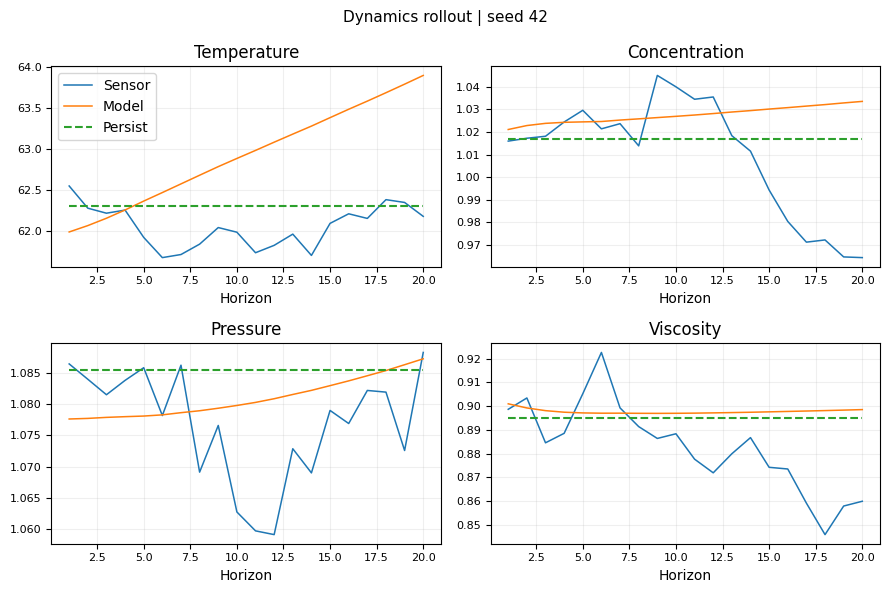

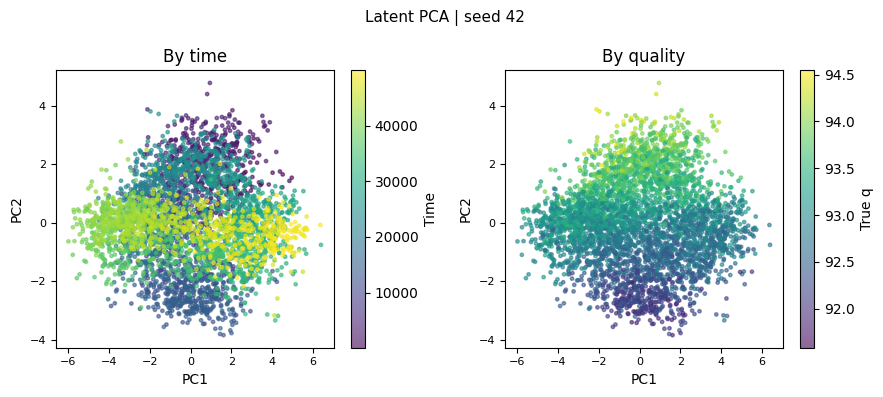

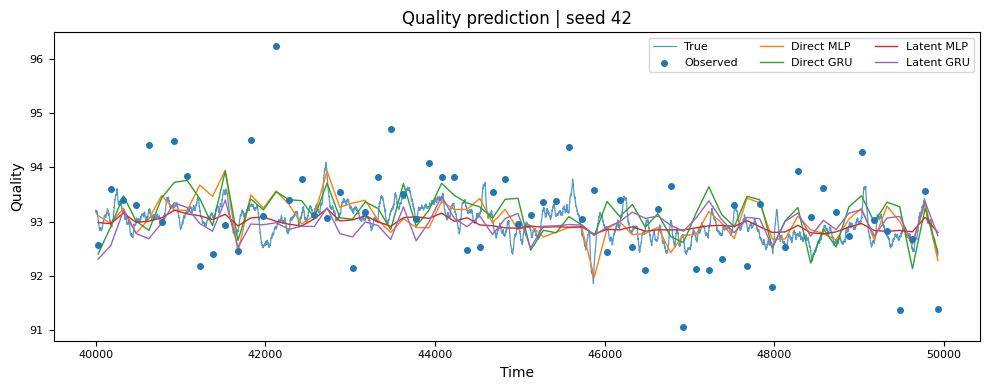

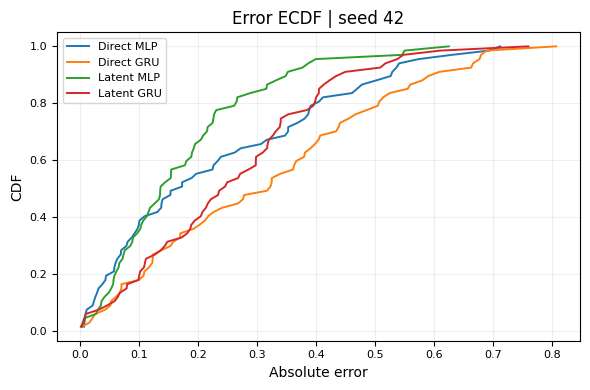

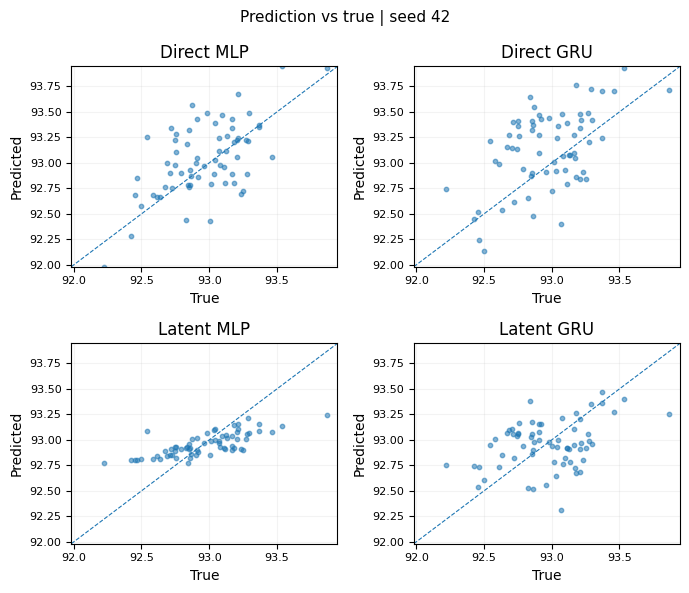

In [64]:
raw_rows = []
prediction_rows = []
timing_rows = []
representative = {}

try:
    seed_bar = progress(
        CFG.seeds,
        desc="v14 seeds",
        total=len(CFG.seeds),
        leave=True,
    )

    for process_seed in seed_bar:
        seed_start = time.perf_counter()
        seed_bar.set_postfix(seed=process_seed)

        data = build_data(CFG, process_seed)

        dynamics_start = time.perf_counter()
        dynamics, dyn_val_mse, persistence_val_mse, dyn_best_epoch = train_dynamics(
            data,
            CFG,
            process_seed,
        )
        Z = compute_latents(dynamics, data["X"], data["U"], CFG)
        Z_scaled, _, _ = standardize_latents(Z, data["train_end"], CFG)
        feature_sets = build_quality_features(data, Z_scaled, CFG)
        dynamics_seconds = time.perf_counter() - dynamics_start

        if process_seed == VISUALIZATION_SEED:
            representative["data"] = data
            representative["dynamics"] = dynamics
            representative["Z_scaled"] = Z_scaled

        quality_seed = process_seed + 100_000
        model_specs = [
            ("direct", "mlp"),
            ("direct", "gru"),
            ("latent", "mlp"),
            ("latent", "gru"),
        ]

        for representation, estimator_type in model_specs:
            model_name = f"{representation}_{estimator_type}"
            model_start = time.perf_counter()

            model, best_epoch, val_pred, test_pred = train_quality_estimator(
                feature_sets[representation],
                data,
                CFG,
                quality_seed,
                representation,
                estimator_type,
            )
            elapsed = time.perf_counter() - model_start

            raw_rows.append({
                "process_seed": process_seed,
                "quality_seed": quality_seed,
                "model": model_name,
                "representation": representation,
                "quality_estimator": estimator_type,
                "parameter_count": parameter_count(model),
                "quality_best_epoch": best_epoch,
                "n_train_labels": data["n_train_labels"],
                "n_val_labels": data["n_val_labels"],
                "n_test_labels": data["n_test_labels"],
                "val_obs_mae": safe_mae(val_pred["observed"], val_pred["prediction"]),
                "val_true_mae_diagnostic": safe_mae(val_pred["true"], val_pred["prediction"]),
                "test_obs_mae": safe_mae(test_pred["observed"], test_pred["prediction"]),
                "test_true_mae_diagnostic": safe_mae(test_pred["true"], test_pred["prediction"]),
                "dyn_val_mse": dyn_val_mse,
                "persistence_val_mse": persistence_val_mse,
                "dyn_best_epoch": dyn_best_epoch,
                "quality_training_seconds": elapsed,
            })

            for t, pred, obs, true in zip(
                test_pred["time"],
                test_pred["prediction"],
                test_pred["observed"],
                test_pred["true"],
            ):
                prediction_rows.append({
                    "process_seed": process_seed,
                    "model": model_name,
                    "feature_time": int(t),
                    "prediction": float(pred),
                    "observed_quality": float(obs),
                    "true_quality_diagnostic": float(true),
                })

        timing_rows.append({
            "process_seed": process_seed,
            "dynamics_and_latent_seconds": dynamics_seconds,
            "total_seed_seconds": time.perf_counter() - seed_start,
        })

    seed_bar.close()

    raw_results = pd.DataFrame(raw_rows)
    predictions = pd.DataFrame(prediction_rows)
    timings = pd.DataFrame(timing_rows)

    save_csv("raw_results.csv", raw_results)
    save_csv("test_predictions.csv", predictions)
    save_csv("timings.csv", timings)

    representative_predictions = predictions[
        predictions["process_seed"] == VISUALIZATION_SEED
    ].copy()

    plot_dynamics_rollout(
        representative["dynamics"],
        representative["data"],
        CFG,
        VISUALIZATION_SEED,
    )
    plot_latent_pca(
        representative["Z_scaled"],
        representative["data"],
        VISUALIZATION_SEED,
    )
    plot_quality_prediction_timeseries(
        representative_predictions,
        representative["data"],
        CFG,
        VISUALIZATION_SEED,
    )
    plot_representative_error_diagnostics(
        representative_predictions,
        VISUALIZATION_SEED,
    )

except Exception:
    (RUN_DIR / "FAILED").write_text(traceback.format_exc(), encoding="utf-8")
    raise

## 11. 結果の集計

モデルごとの平均、標準偏差、seed数を `summary.csv` にまとめる。

`paired_comparisons.csv` には、同じseed内でのMAE差を保存する。定義は `left - right` なので、負ならleft側が良い。平均値だけでなく、seedごとの勝ち負けも確認できる。

In [65]:
summary = (
    raw_results
    .groupby(["model", "representation", "quality_estimator"])
    .agg(
        test_true_mae_mean=("test_true_mae_diagnostic", "mean"),
        test_true_mae_std=("test_true_mae_diagnostic", "std"),
        test_obs_mae_mean=("test_obs_mae", "mean"),
        test_obs_mae_std=("test_obs_mae", "std"),
        val_obs_mae_mean=("val_obs_mae", "mean"),
        parameter_count_mean=("parameter_count", "mean"),
        seed_count=("process_seed", "count"),
    )
    .reset_index()
)

comparison_pairs = [
    ("latent_mlp", "direct_mlp", "representation_effect_mlp"),
    ("latent_gru", "direct_gru", "representation_effect_gru"),
    ("direct_gru", "direct_mlp", "estimator_effect_direct"),
    ("latent_gru", "latent_mlp", "estimator_effect_latent"),
]

paired_rows = []
pivot = raw_results.pivot(
    index="process_seed",
    columns="model",
    values="test_true_mae_diagnostic",
)

for left, right, comparison in comparison_pairs:
    delta = pivot[left] - pivot[right]
    paired_rows.append({
        "comparison": comparison,
        "left_model": left,
        "right_model": right,
        "definition": "left MAE - right MAE; negative favors left",
        "mean_delta": float(delta.mean()),
        "std_delta": float(delta.std(ddof=1)) if len(delta) > 1 else np.nan,
        "left_wins": int((delta < 0).sum()),
        "ties": int((delta == 0).sum()),
        "seed_count": int(delta.notna().sum()),
    })

paired = pd.DataFrame(paired_rows)

save_csv("summary.csv", summary)
save_csv("paired_comparisons.csv", paired)

display(raw_results)
display(summary)
display(paired)

,process_seed,quality_seed,model,representation,quality_estimator,parameter_count,quality_best_epoch,n_train_labels,n_val_labels,n_test_labels,val_obs_mae,val_true_mae_diagnostic,test_obs_mae,test_true_mae_diagnostic,dyn_val_mse,persistence_val_mse,dyn_best_epoch,quality_training_seconds
0,42,100042,direct_mlp,direct,mlp,10301,11,50,66,67,0.666399,0.269690,0.703387,0.231850,0.193726,0.213974,19,0.541869
1,42,100042,direct_gru,direct,gru,10465,35,50,66,67,0.659222,0.320823,0.669606,0.315217,0.193726,0.213974,19,0.684403
2,42,100042,latent_mlp,latent,mlp,11221,4,50,66,67,0.669138,0.230458,0.663943,0.174408,0.193726,0.213974,19,0.374629
3,42,100042,latent_gru,latent,gru,11041,12,50,66,67,0.630092,0.225886,0.687467,0.256717,0.193726,0.213974,19,0.269517
4,43,100043,direct_mlp,direct,mlp,10301,1,50,66,67,0.672591,0.183647,0.608680,0.169084,0.214244,0.239638,15,0.288319
5,43,100043,direct_gru,direct,gru,10465,1,50,66,67,0.784768,0.447650,0.638222,0.344030,0.214244,0.239638,15,0.172298
6,43,100043,latent_mlp,latent,mlp,11221,3,50,66,67,0.697090,0.191635,0.641710,0.247099,0.214244,0.239638,15,0.510690
7,43,100043,latent_gru,latent,gru,11041,1,50,66,67,0.707947,0.212069,0.610960,0.186881,0.214244,0.239638,15,0.206454
8,44,100044,direct_mlp,direct,mlp,10301,10,50,66,67,0.661728,0.208089,0.670145,0.176028,0.197638,0.219401,16,0.514401
9,44,100044,direct_gru,direct,gru,10465,19,50,66,67,0.642808,0.304859,0.709344,0.309845,0.197638,0.219401,16,0.432266


,model,representation,quality_estimator,test_true_mae_mean,test_true_mae_std,test_obs_mae_mean,test_obs_mae_std,val_obs_mae_mean,parameter_count_mean,seed_count
0,direct_gru,direct,gru,0.288907,0.056286,0.659101,0.054184,0.702130,10465.0,5
1,direct_mlp,direct,mlp,0.214543,0.041876,0.655876,0.040644,0.662941,10301.0,5
2,latent_gru,latent,gru,0.209173,0.031535,0.658404,0.048565,0.664895,11041.0,5
3,latent_mlp,latent,mlp,0.256630,0.104944,0.682201,0.068306,0.665150,11221.0,5


,comparison,left_model,right_model,definition,mean_delta,std_delta,left_wins,ties,seed_count
0,representation_effect_mlp,latent_mlp,direct_mlp,left MAE - right MAE; negative favors left,0.042087,0.109963,2,0,5
1,representation_effect_gru,latent_gru,direct_gru,left MAE - right MAE; negative favors left,-0.079735,0.052533,5,0,5
2,estimator_effect_direct,direct_gru,direct_mlp,left MAE - right MAE; negative favors left,0.074364,0.094517,1,0,5
3,estimator_effect_latent,latent_gru,latent_mlp,left MAE - right MAE; negative favors left,-0.047457,0.110124,3,0,5


## 11.1 全seed比較

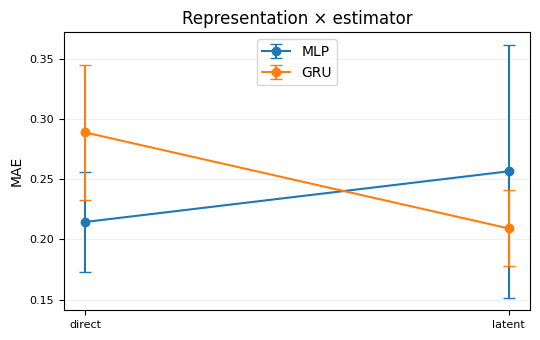

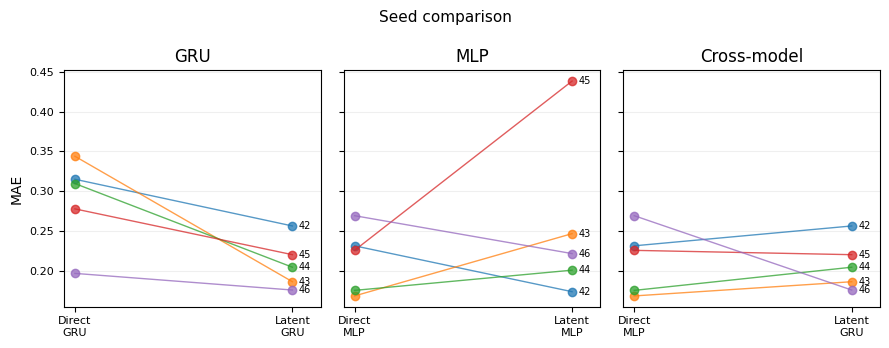

In [66]:
representation_order = ["direct", "latent"]
estimator_order = ["mlp", "gru"]

fig, ax = plt.subplots(figsize=(5.5, 3.5))

for estimator_type in estimator_order:
    means = []
    stds = []

    for representation in representation_order:
        values = raw_results.loc[
            (raw_results["representation"] == representation)
            & (raw_results["quality_estimator"] == estimator_type),
            "test_true_mae_diagnostic",
        ].to_numpy()

        means.append(float(values.mean()))
        stds.append(float(values.std(ddof=1)) if len(values) > 1 else 0.0)

    ax.errorbar(
        representation_order,
        means,
        yerr=stds,
        marker="o",
        linewidth=1.5,
        capsize=4,
        label=estimator_type.upper(),
    )

ax.set_ylabel("MAE")
ax.set_title("Representation × estimator")
ax.legend()
ax.grid(axis="y", alpha=0.2)
ax.tick_params(labelsize=8)
fig.tight_layout()
save_figure(fig, "representation_estimator_interaction.png")

comparison_specs = [
    ("direct_gru", "latent_gru", "GRU"),
    ("direct_mlp", "latent_mlp", "MLP"),
    ("direct_mlp", "latent_gru", "Cross-model"),
]

fig, axes = plt.subplots(1, 3, figsize=(9, 3.5), sharey=True)

for ax, (left_model, right_model, title) in zip(axes, comparison_specs):
    pair = raw_results[
        raw_results["model"].isin([left_model, right_model])
    ].pivot(
        index="process_seed",
        columns="model",
        values="test_true_mae_diagnostic",
    )

    for process_seed_value, row in pair.iterrows():
        ax.plot(
            [0, 1],
            [row[left_model], row[right_model]],
            marker="o",
            linewidth=1.0,
            alpha=0.75,
        )
        ax.text(1.03, row[right_model], str(process_seed_value), fontsize=7, va="center")

    ax.set_xticks([0, 1])
    display_labels = {
        "direct_gru": "Direct" + chr(10) + "GRU",
        "latent_gru": "Latent" + chr(10) + "GRU",
        "direct_mlp": "Direct" + chr(10) + "MLP",
        "latent_mlp": "Latent" + chr(10) + "MLP",
    }
    ax.set_xticklabels([
        display_labels[left_model],
        display_labels[right_model],
    ])
    ax.set_xlim(-0.05, 1.13)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.2)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel("MAE")
fig.suptitle("Seed comparison", fontsize=11)
fig.tight_layout()
save_figure(fig, "paired_seed_comparisons.png")

## 12. 図と終了記録

4モデルの真値MAEを棒グラフで保存する。5 seedで比べた結果では、標本標準偏差を誤差線に使う。

学習データの使い方は `audit.json` に残す。正常終了なら `COMPLETE`、途中で失敗したら `FAILED` を保存する。

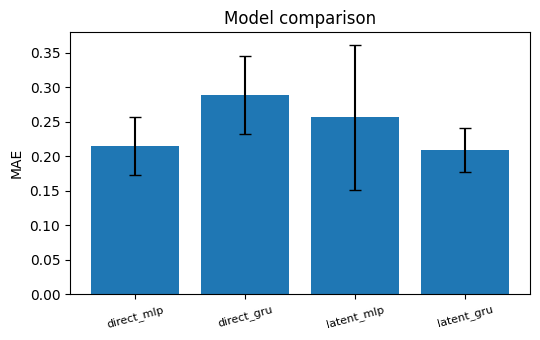

saved to: /content/GRU_soft_sensor_simulation_v14_1_10_results/full
complete: True


In [67]:
plot_order = ["direct_mlp", "direct_gru", "latent_mlp", "latent_gru"]
plot_data = summary.set_index("model").loc[plot_order]

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.bar(
    plot_order,
    plot_data["test_true_mae_mean"],
    yerr=plot_data["test_true_mae_std"].fillna(0.0),
    capsize=4,
)
ax.set_ylabel("MAE")
ax.set_title("Model comparison")
ax.tick_params(axis="x", rotation=15, labelsize=8)
fig.tight_layout()
fig.savefig(RUN_DIR / "model_comparison.png", dpi=160)
plt.show()

audit = {
    "old_simulator_used": True,
    "fixed_condition": {
        "drift_mode": "AR",
        "disturbance_target": "output",
        "disturbance_regime": "persistent",
        "z_dim": CFG.z_dim,
        "train_label_count": CFG.train_label_count,
    },
    "q_true_used_for_training": False,
    "true_state_used_for_training": False,
    "true_drift_used_for_training": False,
    "model_selection_metric": "validation observed-quality SmoothL1 loss",
    "test_used_for_model_selection": False,
    "quality_split": "train by arrival time; validation/test by feature-time window",
    "same_quality_labels_for_all_models": True,
    "same_quality_seed_for_all_models": True,
    "same_history_length_for_mlp_and_gru": True,
    "mlp_history_handling": "flattened fixed-length sequence",
    "mlp_parameter_matching": "hidden width selected to approximate corresponding GRU parameter count",
    "latent_model_frozen_during_quality_training": True,
}
save_json("audit.json", audit)

(RUN_DIR / "RUNNING").unlink(missing_ok=True)
(RUN_DIR / "COMPLETE").write_text("complete\n", encoding="utf-8")

if BACKUP_DIR.exists():
    shutil.rmtree(BACKUP_DIR)
if FINAL_DIR.exists():
    FINAL_DIR.replace(BACKUP_DIR)
RUN_DIR.replace(FINAL_DIR)
if BACKUP_DIR.exists():
    shutil.rmtree(BACKUP_DIR)
RUN_DIR = FINAL_DIR

print("saved to:", RUN_DIR.resolve())
print("complete:", (RUN_DIR / "COMPLETE").exists())

## 13. 結果の見方

`smoke` は処理経路の確認用なので、性能の大小は解釈しない。

`full` の結果では、まず `paired_comparisons.csv` を確認する。

- `representation_effect_mlp`：MLPでの `Latent - Direct`
- `representation_effect_gru`：GRUでの `Latent - Direct`
- `estimator_effect_direct`：生センサ入力での `GRU - MLP`
- `estimator_effect_latent`：latent入力での `GRU - MLP`

差が負なら左側のモデルが良い。真値MAEはシミュレーター内だけで見られる診断値なので、観測品質MAE、seedごとのばらつき、図の傾向も合わせて確認する。